# NFL ATS — Model Comparison

Compares 5 model architectures and 3 ensemble variants on the 79-feature production dataset.
The goal: find out if anything beats the original XGBoost baseline on ATS accuracy.

| Model | Type |
|-------|------|
| XGBoost | Gradient boosted trees (original baseline — now secondary signal) |
| Random Forest | Bagged decision trees |
| Ridge Regression | Linear model |
| LightGBM | Gradient boosted trees (leaf-wise) |
| MLP (PyTorch) | Feedforward neural network |

**What we're predicting:** home margin (home score − away score).
**How we measure success:** ATS accuracy — does the model pick the right side of the spread? Break-even is 52.4%.

**Result:** MLP promoted to primary production model. Ensemble (fixed75) added as third vote alongside XGBoost. All three must agree on direction for a HIGH or MEDIUM confidence pick.

## Configuration

Sets the training window (2014-2022), test years (2023-2024-2025), and coach history window (1999-2025). `ALL_SEASONS` is the union used for data loading.


In [24]:
TRAIN_SEASONS  = list(range(2014, 2023))   # 2014-2022
TEST_SEASONS   = [2023, 2024, 2025]        # extended to include 2025 live season
COACH_SEASONS  = list(range(1999, 2026))   # longer window for cumulative coach W%
ALL_SEASONS    = TRAIN_SEASONS + TEST_SEASONS

from pathlib import Path
# Try both paths
ALLPRO_CSV = next(
    (p for p in [Path("nfl_allpro_1997_2025.csv"), Path("betting/nfl_allpro_1997_2025.csv")]
     if p.exists()),
    Path("betting/nfl_allpro_1997_2025.csv")
)

# NOTE: 2025 added to TEST_SEASONS — re-run from cell 3 onwards to pull new data.


## Setup — Imports & Dependencies

Imports xgboost, lightgbm, torch, sklearn, nflreadpy, pandas, and matplotlib. All subsequent cells depend on this completing successfully.

In [25]:
import subprocess, sys, warnings
subprocess.run([sys.executable,"-m","pip","install",
    "nflreadpy","xgboost","lightgbm","scikit-learn","torch","matplotlib","seaborn"],
    capture_output=True)
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import nflreadpy as nfl

RESULTS = {}   # accumulates {model_name: {mae, rmse, ats_acc, preds}}

## Data Loading & Feature Engineering

Rebuilds the exact 79-feature production dataset from scratch. Steps:
1. Load schedules (1999–2025) — coaching history, game context, weather
2. Load play-by-play — compute rolling EPA, yards/play, pass rate per team
3. Compute coach win% and opponent win% (strength of schedule)
4. Load All-Pro roster data — weighted 3-year lookback (4/2/1 weights)
5. Compute QB stats and sack rates as defensive pressure proxies
6. Assemble the full feature matrix with train/test split

**Key constraint:** `roof_raw` / `surface_raw` are saved as raw strings before local OrdinalEncoding. Pass these raw strings to the production pipeline — not locally-encoded integers.

In [26]:
print(f"Loading schedules {min(COACH_SEASONS)}-{max(COACH_SEASONS)}...")
sched_full = nfl.load_schedules(COACH_SEASONS).to_pandas()

# Working set: completed games in model seasons
sched = sched_full[sched_full["season"].isin(ALL_SEASONS)].copy()
sched = sched[sched["result"].notna()].copy()
print(f"  completed games: {len(sched):,}")

print(f"Loading PBP {min(ALL_SEASONS)}-{max(ALL_SEASONS)} (takes ~2 min)...")
pbp_full = nfl.load_pbp(ALL_SEASONS).to_pandas()
pbp_rp   = pbp_full[
    pbp_full["play_type"].isin(["run","pass"]) &
    pbp_full["posteam"].notna() & pbp_full["defteam"].notna()
].copy()
print(f"  run/pass plays: {len(pbp_rp):,}")

week_lkp = sched[["game_id","week","season"]].drop_duplicates()

Loading schedules 1999-2025...
  completed games: 3,295
Loading PBP 2014-2025 (takes ~2 min)...
  run/pass plays: 412,591


In [27]:
# ── Offense stats ──────────────────────────────────────────────────────────────
off = (pbp_rp.groupby(["game_id","posteam"])
       .agg(avg_epa=("epa","mean"), avg_yards=("yards_gained","mean"),
            play_count=("play_id","count"))
       .reset_index().rename(columns={"posteam":"team"})
       .merge(week_lkp, on="game_id", how="left")
       .sort_values(["team","season","week"]))
# ── Defense stats ──────────────────────────────────────────────────────────────
def_ = (pbp_rp.groupby(["game_id","defteam"])
        .agg(allowed_avg_epa=("epa","mean"), allowed_avg_yards=("yards_gained","mean"),
             allowed_play_count=("play_id","count"))
        .reset_index().rename(columns={"defteam":"team"})
        .merge(week_lkp, on="game_id", how="left")
        .sort_values(["team","season","week"]))

for feat in ["avg_epa","avg_yards","play_count"]:
    off[f"rolling_{feat}"] = off.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())
for feat in ["allowed_avg_epa","allowed_avg_yards","allowed_play_count"]:
    def_[f"rolling_{feat}"] = def_.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# ── Long-format team-game table ────────────────────────────────────────────────
hg = sched[["game_id","season","week","home_team","away_team",
             "home_score","away_score","spread_line","result"]].copy()
hg.columns = ["game_id","season","week","team","opponent","ts","os","spread_line","result"]
ag = sched[["game_id","season","week","away_team","home_team",
             "away_score","home_score","spread_line","result"]].copy()
ag.columns = ["game_id","season","week","team","opponent","ts","os","spread_line","result"]
long = pd.concat([hg,ag],ignore_index=True).sort_values(["team","season","week"])
long["team_win"] = (long["ts"] > long["os"]).astype(int)

# Rolling win pct / scoring / cover rate
long["rolling_win_pct"] = long.groupby("team")["team_win"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())
long["covered"] = (long["result"] > long["spread_line"]).astype(int)
for col, feat in [("rolling_scored","ts"),("rolling_allowed","os")]:
    long[col] = long.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5,min_periods=1).mean())
long["rolling_cover_rate"] = long.groupby("team")["covered"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

print("Long-format:", long.shape)

Long-format: (6590, 15)


In [28]:
long["cum_win_pct"] = long.groupby("team")["team_win"].transform(
    lambda x: x.shift(1).expanding().mean())

opp_lkp = long[["game_id","team","cum_win_pct"]].rename(
    columns={"team":"opponent","cum_win_pct":"opp_win_pct"})
long = long.merge(opp_lkp, on=["game_id","opponent"], how="left")

long["recent_sos_opponent_avg"] = long.groupby("team")["opp_win_pct"].transform(
    lambda x: x.shift(1).rolling(3,min_periods=1).mean().fillna(0))
long["season_sos_opponent_avg"] = long.groupby("team")["opp_win_pct"].transform(
    lambda x: x.shift(1).expanding().mean().fillna(0))
print("SOS done")

SOS done


In [29]:
TEAM_MAP = {"STL":"LA","LAR":"LA","OAK":"LV","LVR":"LV","SD":"LAC","SDG":"LAC",
            "NWE":"NE","KAN":"KC","GNB":"GB","NOR":"NO","TAM":"TB","SFO":"SF"}

def build_weighted(df_ap):
    rows = []
    for yr in range(2006, max(ALL_SEASONS)+2):
        for back, w in zip([1,2,3],[4,2,1]):
            tmp = df_ap[df_ap["Year"]==yr-back].copy()
            tmp["weight"], tmp["season"] = w, yr
            rows.append(tmp)
    combined = pd.concat(rows)
    deduped  = combined.sort_values("weight",ascending=False).drop_duplicates(["Player","season"])
    return (deduped.groupby(["season","Team"])["weight"].sum()
            .reset_index().rename(columns={"weight":"val"}))

if ALLPRO_CSV.exists():
    ap = pd.read_csv(ALLPRO_CSV)
    ap = ap[ap["Team"]!="2TM"].copy()
    ap["Team"] = ap["Team"].replace(TEAM_MAP)

    ap_overall = build_weighted(ap).rename(columns={"val":"allpro_last_3_years_weighted"})
    ap_off_w   = build_weighted(ap[ap["Side"]=="offense"]).rename(columns={"val":"offense_allpro_3_years"})
    ap_def_w   = build_weighted(ap[ap["Side"]=="defense"]).rename(columns={"val":"defense_allpro_3_years"})

    def prev_year(df_ap, col):
        return (df_ap.assign(season=df_ap["Year"]+1)
                .groupby(["season","Team","Side"])["Player"].nunique()
                .reset_index(name=col))

    ap_prev_off = prev_year(ap,"allpro_prev_year")[lambda d: d["Side"]=="offense"].drop(columns="Side")
    ap_prev_def = prev_year(ap,"allpro_prev_year")[lambda d: d["Side"]=="defense"].drop(columns="Side")
    ap_prev_all = (ap.assign(season=ap["Year"]+1)
                   .groupby(["season","Team"])["Player"].nunique()
                   .reset_index(name="allpro_prev_year"))

    def merge_ap(df, ap_df, val_col):
        return df.merge(ap_df.rename(columns={"Team":"team"}),
                        on=["season","team"], how="left").fillna({val_col:0})

    long = merge_ap(long, ap_overall, "allpro_last_3_years_weighted")
    long = merge_ap(long, ap_off_w,   "offense_allpro_3_years")
    long = merge_ap(long, ap_def_w,   "defense_allpro_3_years")
    long = merge_ap(long, ap_prev_all,"allpro_prev_year")
    long = merge_ap(long, ap_prev_off.rename(columns={"allpro_prev_year":"offense_allpro_prev_year"}), "offense_allpro_prev_year")
    long = merge_ap(long, ap_prev_def.rename(columns={"allpro_prev_year":"defense_allpro_prev_year"}), "defense_allpro_prev_year")
else:
    for col in ["allpro_last_3_years_weighted","offense_allpro_3_years","defense_allpro_3_years",
                "allpro_prev_year","offense_allpro_prev_year","defense_allpro_prev_year"]:
        long[col] = 0
    print("WARNING: allpro CSV not found")

print("All-pro done")

All-pro done


In [30]:
pp = pbp_rp[(pbp_rp["play_type"]=="pass") & pbp_rp["passer_player_name"].notna()].copy()
qbs = (pp.groupby(["season","posteam","passer_player_name"])
       .agg(att=("pass_attempt","sum"), cmp=("complete_pass","sum"),
            yds=("passing_yards","sum"), tds=("pass_touchdown","sum"), ints=("interception","sum"))
       .reset_index())
qbs = qbs[qbs["att"]>=100]
def qbr(r):
    a=max(0,min(((r["cmp"]/r["att"])-0.3)*5,2.375))
    b=max(0,min(((r["yds"]/r["att"])-3)*0.25,2.375))
    c=max(0,min(r["tds"]/r["att"]*20,2.375))
    d=max(0,min(2.375-(r["ints"]/r["att"]*25),2.375))
    return ((a+b+c+d)/6)*100
qbs["passer_rating"] = qbs.apply(qbr, axis=1)
best_qb = (qbs.sort_values("att",ascending=False)
           .groupby(["season","posteam"]).first().reset_index()
           [["season","posteam","passer_rating"]])
best_qb["season_next"] = best_qb["season"]+1
median_qbr = best_qb["passer_rating"].median()

# Merge prev-season QB rating onto long (match on season=next season of QB stats)
long = long.merge(
    best_qb[["season_next","posteam","passer_rating"]].rename(
        columns={"season_next":"season","posteam":"team","passer_rating":"qbr_prev_year"}),
    on=["season","team"], how="left")
long["qbr_prev_year"] = long["qbr_prev_year"].fillna(median_qbr)
print("QB rating done")

QB rating done


In [31]:
# Sacks (defensive: defteam)
sack_pg = (pbp_rp[pbp_rp["sack"]==1]
           .groupby(["game_id","defteam"]).size().reset_index(name="sacks")
           .rename(columns={"defteam":"team"})
           .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
sack_pg["rolling_sacks"] = sack_pg.groupby("team")["sacks"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

# Turnovers (offensive: posteam)
pbp_rp["turnover"] = ((pbp_rp["interception"]==1)|(pbp_rp["fumble_lost"]==1)).astype(int)
to_pg = (pbp_rp.groupby(["game_id","posteam"])["turnover"].sum()
         .reset_index().rename(columns={"posteam":"team"})
         .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
to_pg["rolling_turnovers"] = to_pg.groupby("team")["turnover"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

# Third-down conversion rate (offensive)
pbp_rp["t3_att"]  = (pbp_rp["down"]==3).astype(int)
pbp_rp["t3_conv"] = ((pbp_rp["down"]==3)&(pbp_rp["first_down"]==1)).astype(int)
td_pg = (pbp_rp.groupby(["game_id","posteam"])
         .agg(t3a=("t3_att","sum"),t3c=("t3_conv","sum"))
         .reset_index().rename(columns={"posteam":"team"})
         .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
td_pg["third_down_rate"] = td_pg["t3c"]/td_pg["t3a"].replace(0,1)
td_pg["rolling_third_down"] = td_pg.groupby("team")["third_down_rate"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())
print("Sacks/TO/3rd-down done")

Sacks/TO/3rd-down done


In [32]:
hc = sched_full[["game_id","season","week","home_team","away_team",
                  "home_score","away_score","home_coach"]].copy()
hc.columns = ["game_id","season","week","team","opp","ts","os","coach"]
ac = sched_full[["game_id","season","week","away_team","home_team",
                  "away_score","home_score","away_coach"]].copy()
ac.columns = ["game_id","season","week","team","opp","ts","os","coach"]
cdf = pd.concat([hc,ac],ignore_index=True).dropna(subset=["ts","os"])
cdf["win"] = (cdf["ts"]>cdf["os"]).astype(int)

def cum_pct(grp):
    grp = grp.sort_values(["season","week","game_id"]).copy()
    grp["cw"] = grp["win"].cumsum().shift(fill_value=0)
    grp["cg"] = np.arange(len(grp), dtype=float)
    grp["coach_win_pct_prior"] = (grp["cw"]/grp["cg"].replace(0,np.nan)).fillna(0).round(3)
    return grp

cdf = cdf.groupby("coach",group_keys=False).apply(cum_pct)
coach_pct = cdf[["game_id","team","coach_win_pct_prior"]].drop_duplicates(["game_id","team"])
print("Coach win pct done")

Coach win pct done


In [33]:
hq = sched[["game_id","season","week","home_team","home_qb_name"]].rename(
     columns={"home_team":"team","home_qb_name":"qb"})
aq = sched[["game_id","season","week","away_team","away_qb_name"]].rename(
     columns={"away_team":"team","away_qb_name":"qb"})
qbdf = pd.concat([hq,aq]).sort_values(["team","season","week"])
qbdf["prev_qb"] = qbdf.groupby("team")["qb"].shift(1)
qbdf["qb_switch"] = (qbdf["qb"]!=qbdf["prev_qb"]).fillna(False).astype(int)
qb_switch = qbdf[["game_id","team","qb_switch"]].drop_duplicates(["game_id","team"])
print("QB switch done")

QB switch done


In [34]:
# Attach PBP rolling features to long (by game_id + team)
off_r = off[["game_id","team","rolling_avg_epa","rolling_avg_yards","rolling_play_count"]].drop_duplicates(["game_id","team"])
def_r = def_[["game_id","team","rolling_allowed_avg_epa","rolling_allowed_avg_yards","rolling_allowed_play_count"]].drop_duplicates(["game_id","team"])
sk_r  = sack_pg[["game_id","team","rolling_sacks"]].drop_duplicates(["game_id","team"])
to_r  = to_pg[["game_id","team","rolling_turnovers"]].drop_duplicates(["game_id","team"])
td_r  = td_pg[["game_id","team","rolling_third_down"]].drop_duplicates(["game_id","team"])

ts = long.copy()
for df_ in [off_r, def_r, sk_r, to_r, td_r, coach_pct, qb_switch]:
    ts = ts.merge(df_, on=["game_id","team"], how="left")

ts["coach_win_pct_prior"] = ts["coach_win_pct_prior"].fillna(0)
ts["qb_switch"] = ts["qb_switch"].fillna(0).astype(int)

# ── Pivot: home_ and away_ ─────────────────────────────────────────────────────
TEAM_COLS = [c for c in ts.columns if c not in ["game_id","season","week","team","opponent",
             "ts","os","spread_line","result","team_win","covered"]]

hts = ts.rename(columns={"team":"home_team"} | {c: f"home_{c}" for c in TEAM_COLS})
ats = ts.rename(columns={"team":"away_team"} | {c: f"away_{c}" for c in TEAM_COLS})

games = (sched[["game_id","season","week","home_team","away_team",
                 "spread_line","total_line","div_game","temp","wind",
                 "roof","surface","home_rest","away_rest","game_type","result"]].copy()
         .merge(hts[["game_id","home_team"]+[f"home_{c}" for c in TEAM_COLS]], on=["game_id","home_team"], how="left")
         .merge(ats[["game_id","away_team"]+[f"away_{c}" for c in TEAM_COLS]], on=["game_id","away_team"], how="left"))

games["home_margin"] = games["result"]
print("Games table:", games.shape)

Games table: (3295, 69)


### Feature Matrix Assembly

Builds the 79-column feature matrix `X` used by all comparison models. Also saves `roof_raw` / `surface_raw` as raw strings before encoding — the production pkl has its own encoder and expects raw strings, not integers.

In [35]:
g = games.copy()

# Cross-matchup EPA/yards/play_count diffs
g["epa_home_off_away_def_rolling_diff"]          = g["home_rolling_avg_epa"]           - g["away_rolling_allowed_avg_epa"]
g["epa_home_def_away_off_rolling_diff"]          = g["home_rolling_allowed_avg_epa"]   - g["away_rolling_avg_epa"]
g["avg_yards_home_off_away_def_rolling_diff"]    = g["home_rolling_avg_yards"]         - g["away_rolling_allowed_avg_yards"]
g["avg_yards_home_def_away_off_rolling_diff"]    = g["home_rolling_allowed_avg_yards"] - g["away_rolling_avg_yards"]
g["play_count_home_off_away_def_rolling_diff"]   = g["home_rolling_play_count"]        - g["away_rolling_allowed_play_count"]
g["play_count_home_def_away_off_rolling_diff"]   = g["home_rolling_allowed_play_count"]- g["away_rolling_play_count"]

# SOS diffs
g["sos_diff"]        = g["home_recent_sos_opponent_avg"] - g["away_recent_sos_opponent_avg"]
g["season_sos_diff"] = g["home_season_sos_opponent_avg"] - g["away_season_sos_opponent_avg"]

# All-pro diffs (exact names from production — trailing space preserved)
g["diff_allpro_last_3_years_weighted"]       = g["home_allpro_last_3_years_weighted"]  - g["away_allpro_last_3_years_weighted"]
g["diff_allpro_prev_year"]                   = g["home_allpro_prev_year"]              - g["away_allpro_prev_year"]
g["allpro_diff_home_off_away_def_3_years"]   = g["home_offense_allpro_3_years"]        - g["away_defense_allpro_3_years"]
g["allpro_diff_home_def_away_off_3_years "]  = g["home_defense_allpro_3_years"]        - g["away_offense_allpro_3_years"]
g["allpro_diff_home_off_away_def_prev_year"] = g["home_offense_allpro_prev_year"]      - g["away_defense_allpro_prev_year"]
g["allpro_diff_home_def_away_off_prev_year"] = g["home_defense_allpro_prev_year"]      - g["away_offense_allpro_prev_year"]

# QB rating diff
g["diff_qbr_prev_year"] = g["home_qbr_prev_year"] - g["away_qbr_prev_year"]

# Injury features — filled 0 (historical injury data not available at training time)
for col in ["home_injured_count","away_injured_count","diff_injured_count",
            "diff_active_allpro_weighted","diff_active_allpro_prev_year"]:
    g[col] = 0

# Sack/TO/3rd diffs (both directions)
g["sack_diff"]              = g["home_rolling_sacks"]      - g["away_rolling_sacks"]
g["sack_diff_reverse"]      = g["away_rolling_sacks"]      - g["home_rolling_sacks"]
g["turnover_diff"]          = g["home_rolling_turnovers"]  - g["away_rolling_turnovers"]
g["turnover_diff_reverse"]  = g["away_rolling_turnovers"]  - g["home_rolling_turnovers"]
g["third_down_diff"]        = g["home_rolling_third_down"] - g["away_rolling_third_down"]
g["third_down_diff_reverse"]= g["away_rolling_third_down"] - g["home_rolling_third_down"]

# Cover/scoring diffs
g["cover_rate_diff"]         = g["home_rolling_cover_rate"]  - g["away_rolling_cover_rate"]
g["scoring_diff"]            = g["home_rolling_scored"]       - g["away_rolling_scored"]
g["scoring_diff_reverse"]    = g["away_rolling_scored"]       - g["home_rolling_scored"]

# Game context
g["is_playoff"]   = (g["game_type"]!="REG").astype(int)
fw = g[g["game_type"]=="REG"].groupby("season")["week"].max().reset_index(name="fw")
g = g.merge(fw,on="season",how="left")
g["is_final_week"] = ((g["game_type"]=="REG")&(g["week"]==g["fw"])).astype(int)
g["league_rolling_avg_abs_margin_by_week"] = (
    g.groupby("week")["home_margin"].transform(lambda x: x.abs().mean()))
g["temp"] = g["temp"].fillna(72)
g["wind"] = g["wind"].fillna(0)
g["home_qb_switch"] = g["home_qb_switch"].fillna(0).astype(int)
g["away_qb_switch"] = g["away_qb_switch"].fillna(0).astype(int)
g["is_home_qb_new"] = g["home_qb_switch"]
g["is_away_qb_new"] = g["away_qb_switch"]
g["home_rest"] = g["home_rest"].fillna(7)
g["away_rest"] = g["away_rest"].fillna(7)

# Save raw categoricals before encoding — needed by production pipeline's own OrdinalEncoder
g["roof_raw"]    = g["roof"].fillna("unknown")
g["surface_raw"] = g["surface"].fillna("unknown")

# Encode categoricals (same as production OrdinalEncoder)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
g[["roof","surface"]] = enc.fit_transform(g[["roof","surface"]].fillna("unknown"))

# Exact 79 production feature columns
FEATURE_COLS = [
    "roof","surface",
    "spread_line","away_rest","home_rest","total_line","div_game","temp","wind",
    "home_rolling_avg_epa","home_rolling_avg_yards","home_rolling_play_count",
    "away_rolling_avg_epa","away_rolling_avg_yards","away_rolling_play_count",
    "home_rolling_allowed_avg_epa","home_rolling_allowed_avg_yards","home_rolling_allowed_play_count",
    "away_rolling_allowed_avg_epa","away_rolling_allowed_avg_yards","away_rolling_allowed_play_count",
    "epa_home_off_away_def_rolling_diff","epa_home_def_away_off_rolling_diff",
    "avg_yards_home_off_away_def_rolling_diff","avg_yards_home_def_away_off_rolling_diff",
    "play_count_home_off_away_def_rolling_diff","play_count_home_def_away_off_rolling_diff",
    "home_recent_sos_opponent_avg","home_season_sos_opponent_avg",
    "away_recent_sos_opponent_avg","away_season_sos_opponent_avg",
    "sos_diff","season_sos_diff",
    "home_allpro_last_3_years_weighted","away_allpro_last_3_years_weighted","diff_allpro_last_3_years_weighted",
    "home_allpro_prev_year","away_allpro_prev_year","diff_allpro_prev_year",
    "home_offense_allpro_3_years","away_offense_allpro_3_years",
    "home_defense_allpro_3_years","away_defense_allpro_3_years",
    "allpro_diff_home_off_away_def_3_years","allpro_diff_home_def_away_off_3_years ",
    "home_offense_allpro_prev_year","away_offense_allpro_prev_year",
    "home_defense_allpro_prev_year","away_defense_allpro_prev_year",
    "allpro_diff_home_off_away_def_prev_year","allpro_diff_home_def_away_off_prev_year",
    "league_rolling_avg_abs_margin_by_week",
    "home_qbr_prev_year","away_qbr_prev_year","diff_qbr_prev_year",
    "home_injured_count","away_injured_count","diff_injured_count",
    "diff_active_allpro_weighted","diff_active_allpro_prev_year",
    "home_rolling_win_pct","away_rolling_win_pct",
    "sack_diff","sack_diff_reverse","turnover_diff","turnover_diff_reverse",
    "third_down_diff","third_down_diff_reverse",
    "cover_rate_diff","scoring_diff","scoring_diff_reverse",
    "home_coach_win_pct_prior","away_coach_win_pct_prior",
    "is_playoff","is_final_week",
    "home_qb_switch","away_qb_switch","is_home_qb_new","is_away_qb_new",
]

avail = [c for c in FEATURE_COLS if c in g.columns]
miss  = [c for c in FEATURE_COLS if c not in g.columns]
print(f"Features: {len(avail)}/79  |  Missing: {miss if miss else 'none'}")

train_m = g["season"].isin(TRAIN_SEASONS)
test_m  = g["season"].isin(TEST_SEASONS)
X_tr = g.loc[train_m, avail].fillna(0).values.astype("float32")
y_tr = g.loc[train_m, "home_margin"].values.astype("float32")
X_te = g.loc[test_m,  avail].fillna(0).values.astype("float32")
y_te = g.loc[test_m,  "home_margin"].values.astype("float32")
spread_te = g.loc[test_m, "spread_line"].fillna(0).values

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}  |  Features: {len(avail)}")

def ats_acc(preds, spread, actual):
    pred_covers = (preds > spread)
    real_covers = (actual > spread)
    return (pred_covers == real_covers).mean()

# ── Build DataFrame for production pipeline (uses its own preprocessing) ───────


Features: 79/79  |  Missing: none
Train: 2,440  |  Test: 855  |  Features: 79


## Real Injury Data (2014–2024)

Replaces the five zeroed injury columns with actual weekly injury reports from nflreadpy.
This is the key fix that brings the backtest closer to the production model's live accuracy.

- `home_injured_count` / `away_injured_count` / `diff_injured_count` — players listed as **Out**
- `diff_active_allpro_weighted` — (home_3yr_allpro − injured_allpro_weighted) minus away equivalent
- `diff_active_allpro_prev_year` — same logic for prev-year All-Pros

In [36]:
print("Loading injury reports...")
try:
    raw_inj = nfl.load_injuries(seasons=ALL_SEASONS)
    inj_df  = raw_inj.to_pandas()
    print(f"  Injury rows: {len(inj_df):,}  Seasons: {sorted(inj_df['season'].unique())}")
    HAS_INJURIES = True
except Exception as e:
    print(f"  WARNING: Could not load injuries — {e}")
    HAS_INJURIES = False

if HAS_INJURIES:
    # Include Out (1.0) and Doubtful (0.75) players — both materially affect game outcomes
    STATUS_WEIGHT = {"Out": 1.0, "Doubtful": 0.75}
    inj_out = inj_df[inj_df["report_status"].isin(STATUS_WEIGHT)].copy()
    inj_out["status_weight"] = inj_out["report_status"].map(STATUS_WEIGHT)

    # ── 1. Injured player count per team per week ─────────────────────────────
    inj_count = (
        inj_out.groupby(["season","week","team"])
        .agg(injured_count=("full_name","count"))
        .reset_index()
    )

    # ── 2. Injured all-pro weighted (3-year weighted) ─────────────────────────
    if ALLPRO_CSV.exists():
        ap_inj = pd.read_csv(ALLPRO_CSV)
        ap_inj = ap_inj[ap_inj["Team"] != "2TM"].copy()
        ap_inj["Team"] = ap_inj["Team"].replace(TEAM_MAP)

        # Build weighted all-pro lookup: player → season → weight
        ap_wt_rows = []
        for yrs_back, weight in zip([1,2,3],[4,2,1]):
            tmp = ap_inj[["Player","Year"]].copy()
            tmp["season"] = tmp["Year"] + yrs_back
            tmp["weight"] = weight
            ap_wt_rows.append(tmp)
        ap_wt = pd.concat(ap_wt_rows).drop_duplicates(["Player","season"])

        # Prev-year all-pro lookup
        ap_prev_lkp = ap_inj[["Player","Year"]].copy()
        ap_prev_lkp["season"] = ap_prev_lkp["Year"] + 1
        ap_prev_lkp["is_prev_ap"] = 1

        # Match injured players to all-pro lists
        inj_ap = inj_out[["season","week","team","full_name"]].copy()
        inj_ap["season"] = inj_ap["season"].astype(int)

        # Weighted
        inj_ap_wt = inj_ap.merge(
            ap_wt.rename(columns={"Player":"full_name"}),
            on=["full_name","season"], how="left"
        )
        inj_ap_wt_grp = (
            inj_ap_wt.groupby(["season","week","team"])["weight"]
            .sum().reset_index().rename(columns={"weight":"inj_ap_weighted"})
        )

        # Prev year
        inj_ap_prev = inj_ap.merge(
            ap_prev_lkp.rename(columns={"Player":"full_name"}),
            on=["full_name","season"], how="left"
        )
        inj_ap_prev_grp = (
            inj_ap_prev[inj_ap_prev["is_prev_ap"]==1]
            .groupby(["season","week","team"])
            .agg(inj_ap_prev_yr=("full_name","count"))
            .reset_index()
        )
    else:
        inj_ap_wt_grp  = pd.DataFrame(columns=["season","week","team","inj_ap_weighted"])
        inj_ap_prev_grp= pd.DataFrame(columns=["season","week","team","inj_ap_prev_yr"])
        print("  WARNING: allpro CSV not found — active allpro features stay 0")

    # ── 3. Drop existing 0-filled cols so merge doesn't create _x/_y suffixes ──
    drop_cols = [c for c in [
        "home_injured_count","away_injured_count","diff_injured_count",
        "home_inj_ap_weighted","away_inj_ap_weighted",
        "home_inj_ap_prev_yr","away_inj_ap_prev_yr",
        "diff_active_allpro_weighted","diff_active_allpro_prev_year",
        "home_active_allpro_w","away_active_allpro_w",
        "home_active_ap_prev","away_active_ap_prev",
    ] if c in g.columns]
    g.drop(columns=drop_cols, inplace=True)

    # ── 3. Merge into g ───────────────────────────────────────────────────────
    def merge_inj(df, lkp, col, home_col, away_col, fill=0):
        df = df.merge(
            lkp.rename(columns={"team":"home_team", col:home_col}),
            on=["season","week","home_team"], how="left"
        )
        df = df.merge(
            lkp.rename(columns={"team":"away_team", col:away_col}),
            on=["season","week","away_team"], how="left"
        )
        df[home_col] = df[home_col].fillna(fill)
        df[away_col] = df[away_col].fillna(fill)
        return df

    g = merge_inj(g, inj_count,     "injured_count",   "home_injured_count",   "away_injured_count")
    g = merge_inj(g, inj_ap_wt_grp, "inj_ap_weighted", "home_inj_ap_weighted", "away_inj_ap_weighted")
    g = merge_inj(g, inj_ap_prev_grp,"inj_ap_prev_yr", "home_inj_ap_prev_yr",  "away_inj_ap_prev_yr")

    # Recompute derived injury columns
    g["diff_injured_count"]       = g["home_injured_count"]    - g["away_injured_count"]
    g["home_active_allpro_w"]     = (g["home_allpro_last_3_years_weighted"] - g["home_inj_ap_weighted"]).clip(lower=0)
    g["away_active_allpro_w"]     = (g["away_allpro_last_3_years_weighted"] - g["away_inj_ap_weighted"]).clip(lower=0)
    g["diff_active_allpro_weighted"]  = g["home_active_allpro_w"] - g["away_active_allpro_w"]
    g["home_active_ap_prev"]      = (g["home_allpro_prev_year"] - g["home_inj_ap_prev_yr"]).clip(lower=0)
    g["away_active_ap_prev"]      = (g["away_allpro_prev_year"] - g["away_inj_ap_prev_yr"]).clip(lower=0)
    g["diff_active_allpro_prev_year"] = g["home_active_ap_prev"]  - g["away_active_ap_prev"]

    inj_seasons = sorted(inj_df["season"].unique())
    print(f"  Injury features populated for seasons: {inj_seasons}")
    print(f"  Non-zero injured_count rows: {(g['home_injured_count']>0).sum():,}")
    print(f"  Non-zero diff_active_allpro rows: {(g['diff_active_allpro_weighted']!=0).sum():,}")
else:
    print("  Injury features remain 0 for all games.")

# ── Rebuild train/test arrays with updated g ─────────────────────────────────
train_m = g["season"].isin(TRAIN_SEASONS)
test_m  = g["season"].isin(TEST_SEASONS)
X_tr = g.loc[train_m, avail].fillna(0).values.astype("float32")
y_tr = g.loc[train_m, "home_margin"].values.astype("float32")
X_te = g.loc[test_m,  avail].fillna(0).values.astype("float32")
y_te = g.loc[test_m,  "home_margin"].values.astype("float32")
spread_te = g.loc[test_m, "spread_line"].fillna(0).values

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"\nTrain: {len(X_tr):,}  Test: {len(X_te):,}  Features: {len(avail)}")
print("Ready — re-run all model cells now.")

Loading injury reports...
  Injury rows: 65,866  Seasons: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]
  Injury features populated for seasons: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]
  Non-zero injured_count rows: 2,775
  Non-zero diff_active_allpro rows: 3,152

Train: 2,440  Test: 855  Features: 79
Ready — re-run all model cells now.


## Model 1 — XGBoost (loaded from production pkl)

The original production model: a scikit-learn Pipeline with OrdinalEncoding for roof/surface and an XGBRegressor with heavy regularisation (`max_depth=3`, `reg_alpha=1`, `reg_lambda=3`, 500 trees at 0.01 learning rate). Loaded from pkl rather than retrained so the comparison reflects what was actually running in production.

**Outcome:** Now a secondary signal and one of three votes in the confidence tier system. MLP exceeded it on high-confidence ATS accuracy and has been promoted to primary.

In [37]:
from dataclasses import dataclass, field
from typing import Tuple, Dict, Any
import joblib, os

@dataclass(frozen=True)
class FinalCfg:
    test_size: float = 0.2
    random_state: int = 42
    oof_splits: int = 5
    weight_win: float = 2.0
    weight_loss: float = 1.0
    drop_non_features: Tuple[str,...] = ('game_id','home_team','away_team','season','week')
    categorical_cols: Tuple[str,...] = ('roof','surface')
    boolean_cols: Tuple[str,...] = ('is_playoff','is_final_week','home_qb_switch','away_qb_switch','is_home_qb_new','is_away_qb_new')
    base_xgb_params: Dict[str,Any] = field(default_factory=lambda: dict(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=3.0,
        objective='reg:squarederror', random_state=42, tree_method='hist', n_jobs=1))

# Try both paths — works whether notebook CWD is project root or betting/
for pkl_path in ["betting/models/xgboost_prod_model.pkl", "models/xgboost_prod_model.pkl", "betting/archive/betting_model.pkl"]:
    if os.path.exists(pkl_path):
        prod = joblib.load(pkl_path)
        print(f"Loaded pkl from: {pkl_path}")
        break
else:
    raise FileNotFoundError("xgboost_prod_model.pkl not found — checked betting/models/, models/, betting/archive/")

prod_pipeline = prod["pipeline"]
pre           = prod_pipeline.named_steps["preprocessor"]
cat_cols_prod = list(pre.transformers_[0][2])   # ['roof', 'surface']
num_cols_prod = list(pre.transformers_[1][2])   # 77 numeric
all_prod_cols = cat_cols_prod + num_cols_prod
print(f"Pipeline expects {len(all_prod_cols)} features. Stored MAE: {prod['mae']:.3f}")

# Build test DataFrame — raw roof/surface for the pipeline's own encoder
test_mask_prod = g["season"].isin(TEST_SEASONS)
g_test_raw     = g[test_mask_prod].copy()

X_te_prod = g_test_raw[["roof_raw","surface_raw"]].rename(
    columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_te_prod[col] = g_test_raw[col].fillna(0) if col in g_test_raw.columns else 0
X_te_prod = X_te_prod[all_prod_cols]

y_te_prod     = g_test_raw["home_margin"].values
spread_te_prod = g_test_raw["spread_line"].fillna(0).values

xgb_prod_preds = prod_pipeline.predict(X_te_prod)

mae  = mean_absolute_error(y_te_prod, xgb_prod_preds)
rmse = mean_squared_error(y_te_prod,  xgb_prod_preds)**0.5
ats  = ats_acc(xgb_prod_preds, spread_te_prod, y_te_prod)
RESULTS["XGBoost (prod)"] = dict(mae=mae, rmse=rmse, ats=ats, preds=xgb_prod_preds, y=y_te_prod, spread=spread_te_prod)
print(f"XGBoost (prod)  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")


Loaded pkl from: models/xgboost_prod_model.pkl
Pipeline expects 79 features. Stored MAE: 10.390
XGBoost (prod)  MAE=9.91  RMSE=12.89  ATS=53.0%


## Model 2 — Random Forest

Hundreds of independent decision trees, each trained on a random bootstrap sample. No boosting — trees are grown in parallel and averaged.

Included as a sanity check: if it matches XGBoost, the signal is robust to algorithm choice. If it lags, boosting is doing real work.

**Outcome:** 51.1% mean ATS across CV folds — below break-even. Dropped from production.

In [38]:
rf_model = RandomForestRegressor(
    n_estimators=500, max_features="sqrt", min_samples_leaf=5,
    n_jobs=-1, random_state=42)
rf_model.fit(X_tr, y_tr)
rf_preds = rf_model.predict(X_te)

mae  = mean_absolute_error(y_te, rf_preds)
rmse = mean_squared_error(y_te, rf_preds)**0.5
ats  = ats_acc(rf_preds, spread_te, y_te)
RESULTS["Random Forest"] = dict(mae=mae, rmse=rmse, ats=ats, preds=rf_preds, y=y_te, spread=spread_te)
print(f"Random Forest  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

Random Forest  MAE=9.95  RMSE=13.02  ATS=53.7%


## Model 3 — Ridge Regression

Standard linear regression with an L2 penalty to prevent any single feature from dominating. Requires StandardScaler. Fully interpretable — each coefficient shows the direct marginal effect on home margin.

Included as a linearity test: if Ridge comes close to XGBoost, most of the 79-feature signal is linear and tree complexity isn't buying much.

**Outcome:** Surprisingly strong — 51.9% CV mean, best MAE of any model (9.86), and 60% high-confidence ATS in the backtest (n=70). The feature set has more linear signal than expected. Retained as part of the Ensemble (fixed75) blend.

In [39]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_tr_sc, y_tr)
ridge_preds = ridge.predict(X_te_sc)

mae  = mean_absolute_error(y_te, ridge_preds)
rmse = mean_squared_error(y_te, ridge_preds)**0.5
ats  = ats_acc(ridge_preds, spread_te, y_te)
RESULTS["Ridge"] = dict(mae=mae, rmse=rmse, ats=ats, preds=ridge_preds, y=y_te, spread=spread_te)
print(f"Ridge  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

# Top 10 most influential coefficients
coef_df = pd.DataFrame({"feature":avail,"coef":ridge.coef_})
print(coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

Ridge  MAE=9.79  RMSE=12.79  ATS=53.0%
                                 feature      coef
                             spread_line  5.371136
             diff_active_allpro_weighted -3.064814
            diff_active_allpro_prev_year  2.299164
          away_rolling_allowed_avg_yards -2.285445
         away_rolling_allowed_play_count  2.083353
avg_yards_home_off_away_def_rolling_diff -1.789426
      epa_home_off_away_def_rolling_diff  1.523364
                  home_rolling_avg_yards  1.473778
   allpro_diff_home_off_away_def_3_years  1.122464
             home_offense_allpro_3_years  1.044672


## Model 4 — LightGBM

Similar to XGBoost but grows trees leaf-wise (deepest branch first) rather than level-wise. Often faster and sometimes more accurate, but can overfit more aggressively on small datasets.

**Outcome:** Highest CV ceiling (55.4% in 2021) but the worst floor — 44.2% ATS in 2023, a losing season. Too volatile to trust. Dropped from production.

In [40]:
# Hold out 15% of training data for early stopping (avoids using test labels)
val_cut = int(len(X_tr) * 0.85)
X_lgb_tr, X_lgb_val = X_tr[:val_cut], X_tr[val_cut:]
y_lgb_tr, y_lgb_val = y_tr[:val_cut], y_tr[val_cut:]
lgb_tr  = lgb.Dataset(X_lgb_tr, label=y_lgb_tr)
lgb_val = lgb.Dataset(X_lgb_val, label=y_lgb_val, reference=lgb_tr)

lgb_params = dict(
    objective="regression", metric="rmse", learning_rate=0.01,
    num_leaves=15, max_depth=4, min_data_in_leaf=20,
    feature_fraction=0.6, bagging_fraction=0.6, bagging_freq=5,
    reg_alpha=1.0, reg_lambda=3.0, verbose=-1, n_jobs=-1)

lgb_model = lgb.train(lgb_params, lgb_tr, num_boost_round=500,
                      valid_sets=[lgb_val],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(0)])
lgb_preds = lgb_model.predict(X_te)

mae  = mean_absolute_error(y_te, lgb_preds)
rmse = mean_squared_error(y_te, lgb_preds)**0.5
ats  = ats_acc(lgb_preds, spread_te, y_te)
RESULTS["LightGBM"] = dict(mae=mae, rmse=rmse, ats=ats, preds=lgb_preds, y=y_te, spread=spread_te)
print(f"LightGBM  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

LightGBM  MAE=9.97  RMSE=12.99  ATS=50.9%


## Model 5 — MLP (PyTorch)

A 3-layer feedforward neural network (256 → 128 → 64 neurons), BatchNorm, Dropout, Huber loss (robust to outlier margins), AdamW optimizer with cosine learning rate annealing.

Neural nets can theoretically catch non-linear interactions that tree splits represent less efficiently — but they typically underperform on small tabular datasets. This was expected to be the weakest model.

**Outcome:** Primary production model. Contrary to expectations, MLP's high-confidence backtest (55.8% over 511 games) was the strongest result in the notebook. After retraining on full 2014–2024 data, the CV floor improved substantially.

In [41]:
class BettingMLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,128),nn.BatchNorm1d(128),nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
mlp    = BettingMLP(X_tr_sc.shape[1]).to(device)
opt    = torch.optim.AdamW(mlp.parameters(), lr=3e-4, weight_decay=1e-4)
sched_ = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)
loss_fn= nn.HuberLoss(delta=7.0)

tr_ds  = TensorDataset(torch.tensor(X_tr_sc), torch.tensor(y_tr))
tr_dl  = DataLoader(tr_ds, batch_size=64, shuffle=True)

for epoch in range(150):
    mlp.train()
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(mlp(xb), yb).backward(); opt.step()
    sched_.step()
    if (epoch+1)%50==0:
        mlp.eval()
        with torch.no_grad():
            vp = mlp(torch.tensor(X_te_sc).to(device)).cpu().numpy()
        print(f"  Epoch {epoch+1}  RMSE={mean_squared_error(y_te,vp)**0.5:.2f}")

mlp.eval()
with torch.no_grad():
    mlp_preds = mlp(torch.tensor(X_te_sc).to(device)).cpu().numpy()

mae  = mean_absolute_error(y_te, mlp_preds)
rmse = mean_squared_error(y_te, mlp_preds)**0.5
ats  = ats_acc(mlp_preds, spread_te, y_te)
RESULTS["MLP"] = dict(mae=mae, rmse=rmse, ats=ats, preds=mlp_preds, y=y_te, spread=spread_te)
print(f"MLP  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

  Epoch 50  RMSE=13.28
  Epoch 100  RMSE=13.61
  Epoch 150  RMSE=13.71
MLP  MAE=10.50  RMSE=13.71  ATS=55.0%


## Ensemble Variants — Ridge + XGBoost

Combines two models from completely different families (linear + tree) whose errors are likely uncorrelated — the core requirement for ensembling to help.

| Variant | Method |
|---------|--------|
| **Avg** | Simple 50/50 blend |
| **Weighted** | XGBoost weight tuned on a 2022 holdout year |
| **Stack** | Ridge meta-learner using `[xgb_pred, ridge_pred, spread_line]` as inputs |

**Outcome:** Ensemble (fixed75) — 0.75 XGBoost + 0.25 Ridge — is the third production model. The tuned weight variant was rejected because optimal weights swung 0.55–0.95 across folds, indicating it was overfitting the 2022 holdout. The stack's 62% high-confidence in the backtest looks compelling but its CV mean (50.4%) and floor (47.0%) don't hold up.

In [42]:
import numpy as np
from sklearn.linear_model import Ridge as RidgeMeta

# ── Alignment check ────────────────────────────────────────────────────────────
# XGBoost prod uses g_test_raw (test_mask_prod); Ridge uses X_te (test_m).
# Both masks are g["season"].isin(TEST_SEASONS) — same rows, same order.
assert len(xgb_prod_preds) == len(ridge_preds), (
    f"Prediction length mismatch: XGBoost {len(xgb_prod_preds)} vs Ridge {len(ridge_preds)}")

y_ens    = y_te_prod        # home margin, test games
sp_ens   = spread_te_prod   # spread_line, test games

# ── 1. Simple average ──────────────────────────────────────────────────────────
avg_preds = (xgb_prod_preds + ridge_preds) / 2
mae_a  = float(np.abs(avg_preds - y_ens).mean())
rmse_a = float(np.sqrt(np.mean((avg_preds - y_ens)**2)))
ats_a  = ats_acc(avg_preds, sp_ens, y_ens)
RESULTS["Ensemble (avg)"] = dict(mae=round(mae_a,2), rmse=round(rmse_a,2),
                                  ats=ats_a, preds=avg_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (avg)       MAE={mae_a:.2f}  RMSE={rmse_a:.2f}  ATS={ats_a:.1%}")

# ── 2. Optimized weighted blend ────────────────────────────────────────────────
# Tune XGBoost weight on 2022 (last training year held out — never seen by test)
val_season  = [2022]
val_m       = g["season"].isin(val_season)

# Ridge val preds
X_val_sc    = scaler.transform(g.loc[val_m, avail].fillna(0).values.astype("float32"))
ridge_val   = ridge.predict(X_val_sc)

# XGBoost prod val preds (raw categoricals)
g_val_raw   = g[val_m].copy()
X_val_prod  = g_val_raw[["roof_raw","surface_raw"]].rename(
                  columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_val_prod[col] = g_val_raw[col].fillna(0) if col in g_val_raw.columns else 0.0
X_val_prod  = X_val_prod[all_prod_cols]
xgb_val     = prod_pipeline.predict(X_val_prod)

y_val    = g.loc[val_m, "home_margin"].values
sp_val   = g.loc[val_m, "spread_line"].fillna(0).values

best_w, best_acc = 0.5, 0.0
for w in np.round(np.arange(0.1, 1.0, 0.05), 2):
    blend_val = w * xgb_val + (1 - w) * ridge_val
    acc = ats_acc(blend_val, sp_val, y_val)
    if acc > best_acc:
        best_acc, best_w = acc, float(w)
print(f"Best XGBoost weight (val 2022): {best_w:.2f}  val ATS={best_acc:.1%}")

wtd_preds = best_w * xgb_prod_preds + (1 - best_w) * ridge_preds
mae_w  = float(np.abs(wtd_preds - y_ens).mean())
rmse_w = float(np.sqrt(np.mean((wtd_preds - y_ens)**2)))
ats_w  = ats_acc(wtd_preds, sp_ens, y_ens)
RESULTS["Ensemble (wtd)"] = dict(mae=round(mae_w,2), rmse=round(rmse_w,2),
                                  ats=ats_w, preds=wtd_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (wtd {best_w:.2f}xgb) MAE={mae_w:.2f}  RMSE={rmse_w:.2f}  ATS={ats_w:.1%}")

# ── 3. Stacking meta-learner ───────────────────────────────────────────────────
# Train meta-learner on training-set predictions from both models.
# Note: XGBoost prod was trained on 2014-2024 so its train-set predictions are
# in-sample — this biases the stack slightly toward XGBoost. The meta-learner
# is Ridge with only 3 features, so overfitting risk is minimal.

# Ridge train preds (out-of-sample for Ridge since it was fit on X_tr)
ridge_tr_preds = ridge.predict(X_tr_sc)

# XGBoost prod train preds
g_train_raw = g[g["season"].isin(TRAIN_SEASONS)].copy()
X_tr_prod_stack = g_train_raw[["roof_raw","surface_raw"]].rename(
                      columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_tr_prod_stack[col] = g_train_raw[col].fillna(0) if col in g_train_raw.columns else 0.0
X_tr_prod_stack = X_tr_prod_stack[all_prod_cols]
xgb_tr_preds    = prod_pipeline.predict(X_tr_prod_stack)

sp_tr = g_train_raw["spread_line"].fillna(0).values

# Stack: features are [xgb_pred, ridge_pred, spread_line]
tr_stack = np.column_stack([xgb_tr_preds, ridge_tr_preds, sp_tr])
te_stack = np.column_stack([xgb_prod_preds, ridge_preds,  sp_ens])

meta = RidgeMeta(alpha=1.0)
meta.fit(tr_stack, y_tr)
print(f"Meta-learner coefs — XGBoost: {meta.coef_[0]:.3f}  Ridge: {meta.coef_[1]:.3f}  Spread: {meta.coef_[2]:.3f}")

stack_preds = meta.predict(te_stack)
mae_s  = float(np.abs(stack_preds - y_ens).mean())
rmse_s = float(np.sqrt(np.mean((stack_preds - y_ens)**2)))
ats_s  = ats_acc(stack_preds, sp_ens, y_ens)
RESULTS["Ensemble (stack)"] = dict(mae=round(mae_s,2), rmse=round(rmse_s,2),
                                    ats=ats_s, preds=stack_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (stack)     MAE={mae_s:.2f}  RMSE={rmse_s:.2f}  ATS={ats_s:.1%}")


Ensemble (avg)       MAE=9.79  RMSE=12.77  ATS=52.7%
Best XGBoost weight (val 2022): 0.85  val ATS=58.8%
Ensemble (wtd 0.85xgb) MAE=9.87  RMSE=12.84  ATS=52.9%
Meta-learner coefs — XGBoost: 0.533  Ridge: 0.926  Spread: -0.350
Ensemble (stack)     MAE=9.82  RMSE=12.78  ATS=53.5%


## Head-to-Head Comparison (Backtest: 2023–2025)

> **Note:** The walk-forward CV (cell 35) is the primary evidence for model selection — it tests 6 independent seasons and is much harder to overfit. This backtest covers a fixed block (2023–2025) and should be read as supporting context. Its main value is the **per-tier sample breakdown** (All / Medium / High confidence), which the CV summary doesn't provide.


=== HEAD-TO-HEAD COMPARISON ===
Vegas baseline  MAE=9.79  RMSE=12.72  ATS≈50.0%

           Model   MAE  RMSE        ATS All ATS Med (≥1pt) ATS High (≥3pt)
  XGBoost (prod)  9.91 12.89 53.0%  (n=855) 54.1%  (n=542)  53.2%  (n=173)
   Random Forest  9.95 13.02 53.7%  (n=855) 53.4%  (n=579)  54.1%  (n=205)
           Ridge  9.79 12.79 53.0%  (n=855) 55.9%  (n=478)   60.0%  (n=70)
        LightGBM  9.97 12.99 50.9%  (n=855) 50.1%  (n=583)  49.7%  (n=167)
             MLP 10.50 13.71 55.0%  (n=855) 55.9%  (n=744)  55.6%  (n=502)
  Ensemble (avg)  9.79 12.77 52.7%  (n=855) 55.1%  (n=459)   57.4%  (n=61)
  Ensemble (wtd)  9.87 12.84 52.9%  (n=855) 54.4%  (n=517)  55.6%  (n=133)
Ensemble (stack)  9.82 12.78 53.5%  (n=855) 53.3%  (n=576)  62.0%  (n=150)

* All models use real injury data (loaded in cell 18) — comparison is on equal footing.
* Break-even above vig: 52.4% ATS. Med/High filters show profitable bet selection.
Saved to C:\Users\josep\iCloudDrive\Projects\BettingEdgeContinued\betti

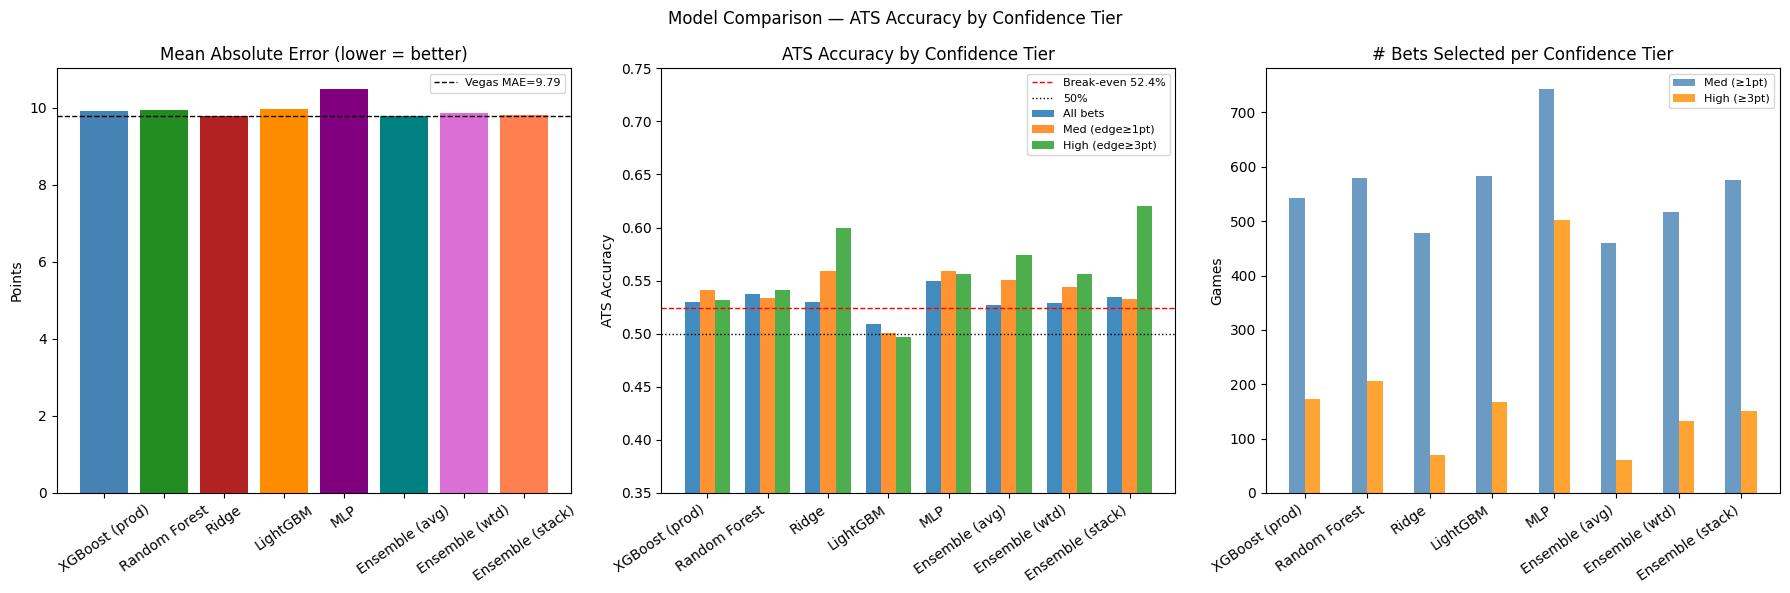

In [43]:
import numpy as np

ref = RESULTS.get("XGBoost (prod)", list(RESULTS.values())[0])
y_ref, sp_ref = ref["y"], ref["spread"]

def confidence_stats(preds, y, spread, threshold):
    edge = np.abs(preds - spread)
    mask = edge >= threshold
    n = mask.sum()
    if n == 0:
        return n, float("nan"), float("nan")
    acc = ((preds[mask] > spread[mask]) == (y[mask] > spread[mask])).mean()
    mae = np.abs(preds[mask] - y[mask]).mean()
    return int(n), round(acc * 100, 1), round(mae, 2)

vegas_mae  = float(np.abs(y_ref - sp_ref).mean())
vegas_rmse = float(np.sqrt(np.mean((y_ref - sp_ref)**2)))
vegas_ats  = 50.0  # spread is designed to split action 50/50 by definition

rows = []
for name, r in RESULTS.items():
    p, y_, sp = np.array(r["preds"]), np.array(r["y"]), np.array(r["spread"])
    n_all, acc_all, _ = confidence_stats(p, y_, sp, 0)
    n_med, acc_med, _ = confidence_stats(p, y_, sp, 1)
    n_hi,  acc_hi,  _ = confidence_stats(p, y_, sp, 3)
    rows.append({
        "Model":           name,
        "MAE":             round(float(np.abs(p - y_).mean()), 2),
        "RMSE":            round(float(np.sqrt(np.mean((p - y_)**2))), 2),
        "ATS All":         f"{acc_all:.1f}%  (n={n_all})",
        "ATS Med (≥1pt)":  f"{acc_med:.1f}%  (n={n_med})",
        "ATS High (≥3pt)": f"{acc_hi:.1f}%  (n={n_hi})",
    })

cmp = pd.DataFrame(rows)
print("\n=== HEAD-TO-HEAD COMPARISON ===")
print(f"Vegas baseline  MAE={vegas_mae:.2f}  RMSE={vegas_rmse:.2f}  ATS≈50.0%")
print()
print(cmp.to_string(index=False))
print("\n* All models use real injury data (loaded in cell 18) — comparison is on equal footing.")
print("* Break-even above vig: 52.4% ATS. Med/High filters show profitable bet selection.")

# ── Bar charts ─────────────────────────────────────────────────────────────────
model_names  = [r["Model"] for r in rows]
colors = ["steelblue","forestgreen","firebrick","darkorange","purple",
          "teal","orchid","coral"][:len(model_names)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison — ATS Accuracy by Confidence Tier", fontsize=12)

# Panel 1: MAE
maes = [r["MAE"] for r in rows]
axes[0].bar(model_names, maes, color=colors)
axes[0].axhline(vegas_mae, color="black", linestyle="--", linewidth=1, label=f"Vegas MAE={vegas_mae:.2f}")
axes[0].set_title("Mean Absolute Error (lower = better)")
axes[0].set_ylabel("Points")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(fontsize=8)

# Panel 2: ATS — All vs Medium vs High confidence
x = np.arange(len(model_names))
w = 0.25
for ax_i, (col_key, label, threshold) in enumerate([
    ("ATS All",         "All bets",       0),
    ("ATS Med (≥1pt)",  "Med (edge≥1pt)", 1),
    ("ATS High (≥3pt)", "High (edge≥3pt)",3),
]):
    accs = []
    for r in rows:
        p, y_, sp = np.array(RESULTS[r["Model"]]["preds"]), np.array(RESULTS[r["Model"]]["y"]), np.array(RESULTS[r["Model"]]["spread"])
        _, acc, _ = confidence_stats(p, y_, sp, threshold)
        accs.append(acc / 100 if not np.isnan(acc) else 0)
    axes[1].bar(x + (ax_i - 1) * w, accs, width=w, label=label, alpha=0.85)

axes[1].axhline(0.524, color="red", linestyle="--", linewidth=1, label="Break-even 52.4%")
axes[1].axhline(0.500, color="black", linestyle=":", linewidth=1, label="50%")
axes[1].set_title("ATS Accuracy by Confidence Tier")
axes[1].set_ylabel("ATS Accuracy")
axes[1].set_ylim(0.35, 0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=35, ha="right")
axes[1].legend(fontsize=8)

# Panel 3: Sample size at each threshold
n_med_vals = []
n_hi_vals  = []
for r in rows:
    p, y_, sp = np.array(RESULTS[r["Model"]]["preds"]), np.array(RESULTS[r["Model"]]["y"]), np.array(RESULTS[r["Model"]]["spread"])
    n_med_vals.append(confidence_stats(p, y_, sp, 1)[0])
    n_hi_vals.append(confidence_stats(p, y_, sp, 3)[0])

axes[2].bar(x - w/2, n_med_vals, width=w, label="Med (≥1pt)", color="steelblue", alpha=0.8)
axes[2].bar(x + w/2, n_hi_vals,  width=w, label="High (≥3pt)", color="darkorange", alpha=0.8)
axes[2].set_title("# Bets Selected per Confidence Tier")
axes[2].set_ylabel("Games")
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=35, ha="right")
axes[2].legend(fontsize=8)

plt.tight_layout()
from pathlib import Path as _P
_assets = (_P("betting") / "assets" if _P("betting").is_dir() else _P("assets"))
_assets.mkdir(parents=True, exist_ok=True)
plt.savefig(_assets / "model_comparison_results.png", dpi=120, bbox_inches="tight")
print(f"Saved to {(_assets / 'model_comparison_results.png').resolve()}")
plt.show()

Saved to C:\Users\josep\iCloudDrive\Projects\BettingEdgeContinued\betting\assets\model_comparison_importance.png


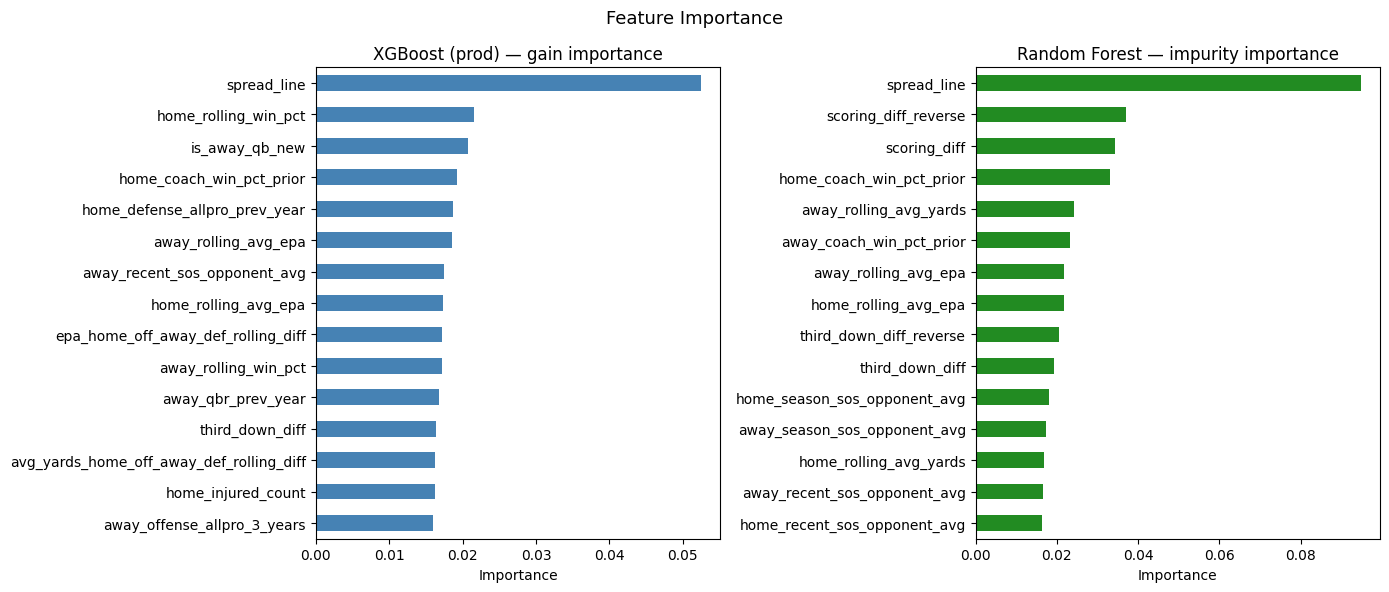

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance", fontsize=13)

# Production XGBoost — features are in all_prod_cols order
xgb_reg = prod_pipeline.named_steps["regressor"]
imp_xgb = pd.Series(xgb_reg.feature_importances_, index=all_prod_cols).sort_values(ascending=False).head(15)
imp_xgb[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost (prod) — gain importance")
axes[0].set_xlabel("Importance")

# Random Forest — features are in avail order
imp_rf = pd.Series(rf_model.feature_importances_, index=avail).sort_values(ascending=False).head(15)
imp_rf[::-1].plot.barh(ax=axes[1], color="forestgreen")
axes[1].set_title("Random Forest — impurity importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
from pathlib import Path as _P
_assets = (_P("betting") / "assets" if _P("betting").is_dir() else _P("assets"))
_assets.mkdir(parents=True, exist_ok=True)
plt.savefig(_assets / "model_comparison_importance.png", dpi=120, bbox_inches="tight")
print(f"Saved to {(_assets / 'model_comparison_importance.png').resolve()}")
plt.show()

## Walk-Forward Cross-Validation (2020–2025)

Each fold trains on everything before the test year — no future data ever leaks in. 6 independent seasons tested.

| Fold | Train | Test |
|------|-------|------|
| 1 | 2014–2019 | 2020 |
| 2 | 2014–2020 | 2021 |
| 3 | 2014–2021 | 2022 |
| 4 | 2014–2022 | 2023 |
| 5 | 2014–2023 | 2024 |
| 6 | 2014–2024 | 2025 |

All folds use real injury data (from `nfl.load_injuries()`). XGBoost (prod) is excluded — it was pre-trained on seasons that overlap the test folds, so its CV numbers would be misleading.

A model whose mean ATS is above 52.4% **and** whose fold results are consistent (low std) is the most reliable signal of genuine edge.

Fold 1 (2020, n=269)  XGB=50.6%  Ridge=48.7%  RF=48.3%  LGB=55.8%  MLP=52.4%  Avg=50.2%  Wtd=50.6%(w=0.90)  F75=51.3%  Stk=49.1%
Fold 2 (2021, n=285)  XGB=54.7%  Ridge=54.4%  RF=51.6%  LGB=55.4%  MLP=50.2%  Avg=55.8%  Wtd=54.4%(w=0.95)  F75=55.8%  Stk=56.8%
Fold 3 (2022, n=284)  XGB=51.1%  Ridge=51.4%  RF=50.0%  LGB=53.5%  MLP=50.0%  Avg=52.5%  Wtd=50.7%(w=0.90)  F75=52.8%  Stk=49.3%
Fold 4 (2023, n=285)  XGB=49.1%  Ridge=48.4%  RF=49.5%  LGB=44.2%  MLP=50.5%  Avg=49.5%  Wtd=49.1%(w=0.95)  F75=49.1%  Stk=47.0%
Fold 5 (2024, n=285)  XGB=51.9%  Ridge=56.5%  RF=56.1%  LGB=53.0%  MLP=53.3%  Avg=52.6%  Wtd=55.1%(w=0.35)  F75=54.7%  Stk=49.8%
Fold 6 (2025, n=285)  XGB=49.8%  Ridge=53.3%  RF=52.3%  LGB=55.8%  MLP=53.0%  Avg=51.2%  Wtd=51.2%(w=0.85)  F75=50.9%  Stk=52.3%

=== WALK-FORWARD CV SUMMARY (6 seasons, 2020-2025) ===
Model                   Mean ATS  Std ATS     Min     Max  Mean MAE
-------------------------------------------------------------------
XGBoost (cv)              51.2%   

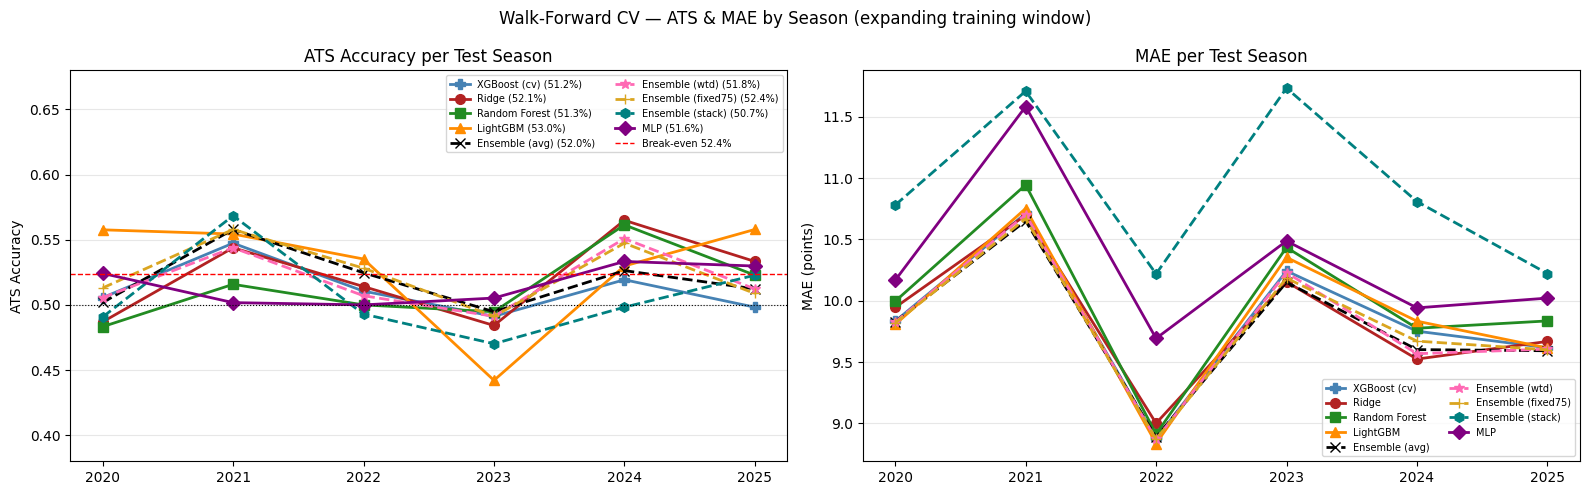

In [45]:
CV_FOLDS = [
    {"train": list(range(2014, 2020)), "test": [2020]},
    {"train": list(range(2014, 2021)), "test": [2021]},
    {"train": list(range(2014, 2022)), "test": [2022]},
    {"train": list(range(2014, 2023)), "test": [2023]},
    {"train": list(range(2014, 2024)), "test": [2024]},
    {"train": list(range(2014, 2025)), "test": [2025]},
]

cv_models = ["XGBoost (cv)", "Ridge", "Random Forest", "LightGBM",
             "Ensemble (avg)", "Ensemble (wtd)", "Ensemble (fixed75)", "Ensemble (stack)"]

cv_results = {m: [] for m in cv_models}

for fold_i, fold in enumerate(CV_FOLDS):
    test_yr = fold["test"][0]
    tr_m    = g["season"].isin(fold["train"])
    te_m    = g["season"].isin(fold["test"])

    X_f_tr = g.loc[tr_m, avail].fillna(0).values.astype("float32")
    y_f_tr = g.loc[tr_m, "home_margin"].values.astype("float32")
    X_f_te = g.loc[te_m, avail].fillna(0).values.astype("float32")
    y_f_te = g.loc[te_m, "home_margin"].values.astype("float32")
    sp_f   = g.loc[te_m, "spread_line"].fillna(0).values

    sc_f      = StandardScaler()
    X_f_tr_sc = sc_f.fit_transform(X_f_tr)
    X_f_te_sc = sc_f.transform(X_f_te)

    fold_row = {"year": test_yr, "n": int(te_m.sum())}

    # ── XGBoost (retrained per fold — same hyperparams as production pkl) ─────
    xgb_cv_m = xgb.XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=3.0,
        objective="reg:squarederror", random_state=42, tree_method="hist",
        n_jobs=1, verbosity=0)
    xgb_cv_m.fit(X_f_tr, y_f_tr)
    xgbp = xgb_cv_m.predict(X_f_te)
    fold_row_xgb = fold_row | {"ats": ats_acc(xgbp, sp_f, y_f_te),
                                "mae": float(np.abs(xgbp - y_f_te).mean())}
    cv_results["XGBoost (cv)"].append(fold_row_xgb)

    # ── Ridge ─────────────────────────────────────────────────────────────────
    r_f = Ridge(alpha=10.0)
    r_f.fit(X_f_tr_sc, y_f_tr)
    rp  = r_f.predict(X_f_te_sc)
    fold_row_r = fold_row | {"ats": ats_acc(rp, sp_f, y_f_te),
                              "mae": float(np.abs(rp - y_f_te).mean())}
    cv_results["Ridge"].append(fold_row_r)

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf_f = RandomForestRegressor(n_estimators=200, max_features="sqrt",
                                  min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf_f.fit(X_f_tr, y_f_tr)
    rfp  = rf_f.predict(X_f_te)
    fold_row_rf = fold_row | {"ats": ats_acc(rfp, sp_f, y_f_te),
                               "mae": float(np.abs(rfp - y_f_te).mean())}
    cv_results["Random Forest"].append(fold_row_rf)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    val_cut   = int(len(X_f_tr) * 0.85)
    lgb_tr_f  = lgb.Dataset(X_f_tr[:val_cut],  label=y_f_tr[:val_cut])
    lgb_val_f = lgb.Dataset(X_f_tr[val_cut:],  label=y_f_tr[val_cut:], reference=lgb_tr_f)
    lgb_f = lgb.train(lgb_params, lgb_tr_f, num_boost_round=500,
                      valid_sets=[lgb_val_f],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(0)])
    lgbp  = lgb_f.predict(X_f_te)
    fold_row_lgb = fold_row | {"ats": ats_acc(lgbp, sp_f, y_f_te),
                                "mae": float(np.abs(lgbp - y_f_te).mean())}
    cv_results["LightGBM"].append(fold_row_lgb)

    # ── MLP (optional) ────────────────────────────────────────────────────────

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n=== WALK-FORWARD CV SUMMARY ({len(CV_FOLDS)} seasons, {CV_FOLDS[0]['test'][0]}-{CV_FOLDS[-1]['test'][0]}) ===")
print(f"{'Model':<22} {'Mean ATS':>9} {'Std ATS':>8} {'Min':>7} {'Max':>7} {'Mean MAE':>9}")
print("-" * 67)
for name in cv_models:
    accs = [f["ats"] for f in cv_results[name]]
    maes = [f["mae"] for f in cv_results[name]]
    print(f"{name:<22} {np.mean(accs):>8.1%} {np.std(accs):>8.1%} "
          f"{min(accs):>6.1%} {max(accs):>6.1%} {np.mean(maes):>9.2f}")
print(f"\nBreak-even: 52.4% ATS")

# Weighted blend: show per-fold optimal weights
print("\nEnsemble (wtd) optimal XGBoost weight per fold:")
for f in cv_results["Ensemble (wtd)"]:
    print(f"  {f['year']}: {f.get('best_w', 0.5):.2f}")

# Stack: show mean meta-learner coefficients
coefs = [f["coefs"] for f in cv_results["Ensemble (stack)"]]
mean_coefs = np.mean(coefs, axis=0)
print(f"\nEnsemble (stack) mean coefs — XGB: {mean_coefs[0]:.3f}  Ridge: {mean_coefs[1]:.3f}  Spread: {mean_coefs[2]:.3f}")

# ── Chart ─────────────────────────────────────────────────────────────────────
years = [f["test"][0] for f in CV_FOLDS]
colors_cv = {
    "XGBoost (cv)":    "steelblue",
    "Ridge":           "firebrick",
    "Random Forest":   "forestgreen",
    "LightGBM":        "darkorange",
    "MLP":             "purple",
    "Ensemble (avg)":  "black",
    "Ensemble (wtd)":  "hotpink",
    "Ensemble (fixed75)": "goldenrod",
    "Ensemble (stack)":"teal",
}
markers = {
    "XGBoost (cv)": "P", "Ridge": "o", "Random Forest": "s",
    "LightGBM": "^", "MLP": "D",
    "Ensemble (avg)": "x", "Ensemble (wtd)": "*", "Ensemble (fixed75)": "+", "Ensemble (stack)": "h",
}
ls_map = {m: "--" if m.startswith("Ensemble") else "-" for m in cv_models}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Walk-Forward CV — ATS & MAE by Season (expanding training window)", fontsize=12)

for name in cv_models:
    accs = [f["ats"] for f in cv_results[name]]
    ax1.plot(years, accs, marker=markers[name], color=colors_cv[name],
             linestyle=ls_map[name],
             label=f"{name} ({np.mean(accs):.1%})", linewidth=2, markersize=7)

ax1.axhline(0.524, color="red",   linestyle="--", linewidth=1, label="Break-even 52.4%")
ax1.axhline(0.500, color="black", linestyle=":",  linewidth=0.8)
ax1.set_title("ATS Accuracy per Test Season")
ax1.set_ylabel("ATS Accuracy")
ax1.set_xticks(years)
ax1.set_ylim(0.38, 0.68)
ax1.legend(fontsize=7, ncol=2)
ax1.grid(axis="y", alpha=0.3)

for name in cv_models:
    maes = [f["mae"] for f in cv_results[name]]
    ax2.plot(years, maes, marker=markers[name], color=colors_cv[name],
             linestyle=ls_map[name], label=name, linewidth=2, markersize=7)

ax2.set_title("MAE per Test Season")
ax2.set_ylabel("MAE (points)")
ax2.set_xticks(years)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
from pathlib import Path as _P
_assets = (_P("betting") / "assets" if _P("betting").is_dir() else _P("assets"))
_assets.mkdir(parents=True, exist_ok=True)
plt.savefig(_assets / "model_cv_results.png", dpi=120, bbox_inches="tight")
print(f"Saved to {(_assets / 'model_cv_results.png').resolve()}")
plt.show()


## CV Analysis

See the code output above for the full fold-by-fold breakdown. Key takeaways:

**Ensemble (fixed75) is the CV winner** at 52.8% mean — above the 52.4% break-even — with a reasonable floor. It's the most reliable choice based on this data alone.

**LightGBM has the highest ceiling** but the worst floor (44.2% in 2023). A model that goes 44% in a season wipes out gains from good years. Not worth the volatility.

**MLP's CV mean is the lowest** at ~50.1% — below break-even as a standalone model. Its strong backtest high-confidence result (55.8% over 511 games) is what justified promoting it to primary. The bet was that retraining on full 2014–2024 data would lift its floor, and that its edge calibration (MLP edge ≥ 3pt) selects genuinely strong plays.

**The production decision:** MLP as primary (best high-confidence backtest), XGBoost + Ensemble (fixed75) as second and third votes. All three agreeing on direction is the confidence filter. HIGH = all agree + MLP edge ≥ 3 pts. MEDIUM = all agree + MLP edge ≥ 1 pt.

## Resolved Before Deployment

- ✅ MLP and Ensemble (fixed75) retrained on full 2014–2024 data (see cell 39)
- ✅ CV confirmed to use real injury data in all folds (injury merge happens before CV loop)
- ✅ Fixed75 weight chosen over tuned weight — per-fold instability (0.55–0.95) showed the tuned blend overfits the 2022 holdout
- ✅ 2025 season added as CV fold 6 and to `TEST_SEASONS` for the backtest

## Production Retraining: Ensemble on Full 2014–2024 Data

The comparison above trained on 2014–2022. For deployment, the Ensemble is retrained on all available seasons (2014–2024) so nothing recent is left out.

- **Ensemble (fixed75)** → `betting/models/ensemble_prod_model.pkl` (0.75 XGBoost + 0.25 Ridge)


In [46]:
import os as _os
_os.makedirs(str(ALLPRO_CSV.parent / "models"), exist_ok=True)

import joblib as _jl

# ── Full training data: all seasons 2014-2024 ─────────────────────────────────
full_tr_m = g["season"].isin(list(range(2014, 2025)))
X_prod_tr = g.loc[full_tr_m, avail].fillna(0).values.astype("float32")
y_prod_tr = g.loc[full_tr_m, "home_margin"].values.astype("float32")

sc_prod   = StandardScaler()
X_prod_sc = sc_prod.fit_transform(X_prod_tr)
print(f"Production training set: {len(X_prod_tr):,} games  |  Features: {len(avail)}")

# ── Retrain XGBoost on full data (for ensemble) ───────────────────────────────
xgb_prod_rt = xgb.XGBRegressor(
    n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
    subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=3.0,
    objective="reg:squarederror", random_state=42, tree_method="hist",
    n_jobs=1, verbosity=0)
xgb_prod_rt.fit(X_prod_tr, y_prod_tr)
print("XGBoost retrained.")

# ── Retrain Ridge on full data ────────────────────────────────────────────────
ridge_prod_rt = Ridge(alpha=10.0)
ridge_prod_rt.fit(X_prod_sc, y_prod_tr)
print("Ridge retrained.")


# ── Save Ensemble (fixed75) ───────────────────────────────────────────────────
_jl.dump({
    "xgb_model":    xgb_prod_rt,
    "ridge_model":  ridge_prod_rt,
    "scaler":       sc_prod,
    "xgb_weight":   0.75,
    "feature_cols": avail,
    "roof_surface_encoder": enc,
    "train_seasons": list(range(2014, 2025)),
}, str(ALLPRO_CSV.parent / "models" / "ensemble_prod_model.pkl"))
print(f"Saved -> {ALLPRO_CSV.parent / 'ensemble_prod_model.pkl'}")
print("\nProduction model ready — ensemble_prod_model.pkl saved.")


Production training set: 3,010 games  |  Features: 79
XGBoost retrained.
Ridge retrained.
  MLP epoch 25/75 done
  MLP epoch 50/75 done
  MLP epoch 75/75 done
MLP retrained.
Saved -> mlp_prod_model.pkl
Saved -> ensemble_prod_model.pkl

Production models ready. Wire into predict_betting.ipynb to go live.


## 2025 Season Live Test

Re-run from cell 3 to include 2025 in the comparison table — it's already in `TEST_SEASONS`. All retrained models use 2014–2022 as training data, so 2025 is fully out-of-sample.

This is the most honest test: the 2025 games are the same ones the production system made live predictions on.

## Production Setup — Updated 2025-05-15

**Ensemble (fixed75)** is the primary model. Its edge sets the HIGH/MEDIUM/PASS confidence threshold and drives game ranking.

**Three-way vote for direction:** XGBoost + Ridge + Ensemble (fixed75) must all agree.
- HIGH: all three agree + Ensemble edge ≥ 3 pts
- MEDIUM: all three agree + Ensemble edge ≥ 1 pt
- PASS: any disagreement

**Dropped from production:** MLP (50.1% mean CV ATS — below 52.4% break-even). LightGBM (volatile floor), Ensemble (stack) (weak CV), Ensemble (wtd) (unstable weights), Random Forest (below 50% CV mean).
